# Packages

In [1]:
import sys
sys.path.append('/home/boscoll/github/CDKPredict/code')
from CDKPredict_scalable import CDKPredict_scalable
import matplotlib as mpl
import pickle
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from helper_functions import *

# Data load

In [2]:
project_path = Path('/home/boscoll/Projects/cdk_predict')
train_test_split = project_path / 'data/development_cohort/train_test_split/genomic_train_test_split_msk_final'
clinical_path = project_path / 'data/development_cohort/clinical/clinical_msk_final.csv'


with open(train_test_split, 'rb') as f:
    X_genomic_train, X_genomic_test, y_train, y_test = pickle.load(f)
y_train = y_train[['Time', 'Event']].copy()

clinical = pd.read_csv(clinical_path, index_col=0)

#merged clinicogenomic
X_clinicogenomic_train = pd.concat([X_genomic_train[['TP53_tsg', 'ESR1_mut', 'RB1_tsg', 'BRCA2_tsg', 'BRCA1_tsg', 'PTEN_tsg', 'AKT1_mut', 'PIK3CA_mut']], clinical.loc[lambda x: x.index.isin(X_genomic_train.index)]], axis=1)
X_clinicogenomic_test = pd.concat([X_genomic_test[['TP53_tsg', 'ESR1_mut', 'RB1_tsg', 'BRCA2_tsg', 'BRCA1_tsg', 'PTEN_tsg', 'AKT1_mut', 'PIK3CA_mut']], clinical.loc[lambda x: x.index.isin(X_genomic_test.index)]], axis=1)
X_clinicogenomic_train = X_clinicogenomic_train.reindex(y_train.index)
X_clinicogenomic_test = X_clinicogenomic_test.reindex(y_test.index)

#from the clinical only dataframe, remove the 'met_sample' variable
X_clinical_train = clinical.loc[X_genomic_train.index].copy()
X_clinical_test = clinical.loc[X_genomic_test.index].copy()
X_clinical_train.drop(columns='met_sample', inplace=True)
X_clinical_test.drop(columns='met_sample', inplace=True)

In [3]:
palette = {'high':'#FF3030', 'intermediate':'#EEB422', 'low':'#228B22'}

# Data load

In [4]:
#clinicogenomic model
CDKPredictS_clinicogenomic = CDKPredict_scalable(
    n_models = 100, 
    l1 = 1, 
    n_folds=3, 
    bootstrap=True,
    random_state=94, 
    adaptive_lasso=True, 
    normalization = (0.01, 0.99), 
    metric = 'auc', 
    auc_time_range =(3, 36), 
)

#clinical model
CDKPredictS_clin = CDKPredict_scalable(
    n_models = 100, 
    l1 = 1, 
    n_folds=3, 
    bootstrap=True,
    random_state=94, 
    adaptive_lasso=True, 
    normalization = (0.01, 0.99), 
    metric = 'auc', 
    auc_time_range =(3, 36), 
)

In [5]:
CDKPredictS_clinicogenomic.fit(X_clinicogenomic_train, y_train)
CDKPredictS_clin.fit(X_clinical_train, y_train)

Fitting 100 base learners...
Selected `bootstrap` sampling for model fitting
Selected the option `adaptive_lasso` to assign distinct penalty to different coefficients
Using time-dependent AUC as model selection metric...
Using user-defined AUC time range for hyperparameter tuning: (3, 36)
Finished fitting 100 models.
Fitting 100 base learners...
Selected `bootstrap` sampling for model fitting
Selected the option `adaptive_lasso` to assign distinct penalty to different coefficients
Using time-dependent AUC as model selection metric...
Using user-defined AUC time range for hyperparameter tuning: (3, 36)
Finished fitting 100 models.


In [6]:
CDKPredictS_clinicogenomic.define_3_risk_groups(plot=False)
CDKPredictS_clin.define_3_risk_groups(plot=False)

cutoff between low and intermediate risk calculated at: 9.86, cutoff between intermediate and high risk calculated at: 42.21
cutoff between low and intermediate risk calculated at: 16.32, cutoff between intermediate and high risk calculated at: 62.43


In [7]:
PFS = CDKPredictS_clinicogenomic.get_train_risk_groups_3().to_frame().join(y_train)

In [8]:
PFS_test = CDKPredictS_clinicogenomic.predict(X_clinicogenomic_test, classify=True, groups = 3).to_frame().merge(y_test, left_index=True, right_index=True)
PFS_test_clin = CDKPredictS_clin.predict(X_clinical_test, classify=True, groups = 3).to_frame().merge(y_test, left_index=True, right_index=True)

Activated the classify option, returning risk groups instead of continuous risk scores.
Activated the classify option, returning risk groups instead of continuous risk scores.


**Supplementary Table 13**

In [ ]:
# ###save table for internal train
# df_save = CDKPredictS_clinicogenomic.get_train_risk_groups_3().to_frame().join(CDKPredictS_clinicogenomic.risk_scores_train).rename(columns={'risk_score':'clinicogenomic_risk_score', 'risk_group':'clinicogenomic_risk_group'})\
# .join(
# CDKPredictS_clin.get_train_risk_groups_3().to_frame().join(CDKPredictS_clin.risk_scores_train).rename(columns={'risk_score':'clinical_risk_score', 'risk_group':'clinical_risk_group'})
# ).join(y_train)
# df_save.to_excel('/home/boscoll/Projects/cdk_predict/results/tables/scalable_model_msk_train.xlsx')

In [ ]:
###save table for internal test
# df_save = CDKPredictS_clinicogenomic.predict(X_clinicogenomic_test, classify=False).to_frame().join(PFS_test).rename(columns={'risk_score':'clinicogenomic_risk_score', 'risk_group':'clinicogenomic_risk_group'})\
# .join(
#     CDKPredictS_clin.predict(X_clinical_test, classify=False).to_frame().join(PFS_test_clin).rename(columns={'risk_score':'clinical_risk_score', 'risk_group':'clinical_risk_group'}).drop(columns=['Event', 'Time'])
# )
# df_save = df_save[[col for col in df_save.columns if col not in ['Event', 'Time']] + ['Time', 'Event']]
# df_save.index = df_save.index.map(key_msk.key_col)
# df_save.to_excel('/home/boscoll/Projects/cdk_predict/results/tables/scalable_model_msk_test.xlsx')

The option `classify` is set to False, returning continuous risk scores.
Dropping extra columns in test not seen in training, n. columns: 1
The option `classify` is set to False, returning continuous risk scores.


**Fig. 6b**

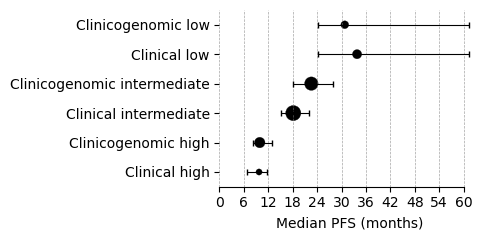

In [11]:
# clinicogenomic
# Call: survfit(formula = Surv(Time, Event) ~ risk_group, data = PFS_test)

#                     n events median 0.95LCL 0.95UCL
# risk_group=low     74     41  30.78   24.15    61.4
# risk_group=medium 186    121  22.57   18.13    27.9
# risk_group=high   120     99   9.89    8.31    13.0
# Call:
# coxph(formula = Surv(Time, Event) ~ risk_group, data = PFS_test)


#clinical
# Call: survfit(formula = Surv(Time, Event) ~ risk_group, data = PFS_test_clin)

#                     n events median 0.95LCL 0.95UCL
# risk_group=low     96     51  33.80    24.1    61.4
# risk_group=medium 231    166  18.13    15.2    22.1
# risk_group=high    53     44   9.72     6.7    11.6
# Call:
# coxph(formula = Surv(Time, Event) ~ risk_group, data = PFS_test_clin)


plot_df = pd.DataFrame({
    'Cohort': ['Clinicogenomic low', 'Clinical low', 'Clinicogenomic intermediate', 'Clinical intermediate', 'Clinicogenomic high', 'Clinical high'],
    'mPFS' : [30.78, 33.80, 22.57, 18.13, 9.89, 9.72],
    'upper_CI' : [61.4, 61.4, 27.9, 22.1, 13.0, 11.6],
    'lower_CI' : [24.15, 24.1, 18.13, 15.2, 8.31, 6.7], 
    'nr' : [74, 96, 186, 231, 120, 53]
})
plot_df = plot_df.iloc[::-1]

#forestplot with mPFS and conf int 
plt.figure(figsize=(5, 2.5))
nr_min = plot_df['nr'].min()
nr_max = plot_df['nr'].max()
plot_df['nr_normalized'] = (plot_df['nr'] - nr_min) / (nr_max - nr_min) * 100 + 20 
plt.grid(axis='x', linestyle='--', linewidth=0.5, color='gray', alpha=0.7)
plt.scatter(x=plot_df['mPFS'], y=plot_df['Cohort'], color='black', s=plot_df['nr_normalized'], marker='o', linewidths=0.2)
plt.errorbar(x=plot_df['mPFS'], y=plot_df['Cohort'], 
             xerr=[plot_df['mPFS'] - plot_df['lower_CI'], 
                    plot_df['upper_CI'] - plot_df['mPFS']], fmt='o', color='black', ecolor='black', capsize=2,
                      markersize=1.5, linewidth=0.8)

plt.xlabel('Median PFS (months)')
plt.ylabel('')
plt.xlim(0, 64)
plt.ylim(-0.5, len(plot_df)-0.5)
plt.xticks([0, 6, 12, 18, 24, 30, 36, 42, 48, 54, 60])
plt.tight_layout()
sns.despine(trim = True, left = True)
# plt.savefig('/scratch/razavip/boscoll/cdk_predict/results/images/paper_figures/minimal_model/forest_plot_scalable_msk.pdf', bbox_inches='tight')
plt.show()


### Fine tune CDKPredict-S on the full development cohort before deployment

In [12]:
X_msk_clinicogenomic = pd.concat([X_clinicogenomic_train, X_clinicogenomic_test])
X_msk_clin = pd.concat([X_clinical_train, X_clinical_test])
y_msk = pd.concat([y_train, y_test])

In [13]:
CDKPredictS_clinicogenomic.fit(X_msk_clinicogenomic.drop(columns=['met_sample']), y_msk) 
#for IEO-CDK, met sample all missing, exclude from the deployed model, also to facilitate deployment where the sample used for sequencing many times is uknown

CDKPredictS_clin.fit(X_msk_clin, y_msk)

Fitting 100 base learners...
Selected `bootstrap` sampling for model fitting
Selected the option `adaptive_lasso` to assign distinct penalty to different coefficients
Using time-dependent AUC as model selection metric...
Using user-defined AUC time range for hyperparameter tuning: (3, 36)
Finished fitting 100 models.
Fitting 100 base learners...
Selected `bootstrap` sampling for model fitting
Selected the option `adaptive_lasso` to assign distinct penalty to different coefficients
Using time-dependent AUC as model selection metric...
Using user-defined AUC time range for hyperparameter tuning: (3, 36)
Finished fitting 100 models.


**Extended Data Fig. 9a**

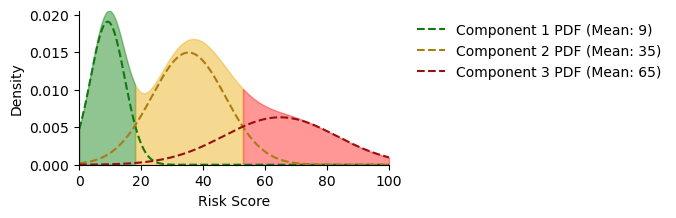

cutoff between low and intermediate risk calculated at: 18.02, cutoff between intermediate and high risk calculated at: 52.79


In [17]:
CDKPredictS_clin.define_3_risk_groups(plot=True, legend=True, bins = 20, figsize=(4, 2), detailed = False, 
                                    # save = '/scratch/razavip/boscoll/cdk_predict/results/images/paper_figures/minimal_model/risk_groups_clinical_msk.pdf'
                                    )

In [ ]:
# CDKPredictS_clin.save_model('/home/boscoll/Projects/cdk_predict/results/models_selection/models/scalable_models/cdkpredict_scalable_clinical_final.pkl')

Model saved to /home/boscoll/Projects/cdk_predict/results/models_selection/models/scalable_models/cdkpredict_scalable_clinical_final.pkl


**Extended Data Fig. 9b**

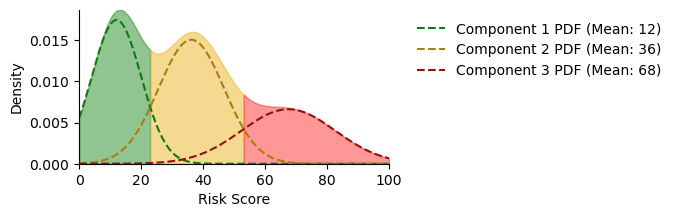

cutoff between low and intermediate risk calculated at: 22.90, cutoff between intermediate and high risk calculated at: 53.09


In [19]:
CDKPredictS_clinicogenomic.define_3_risk_groups(plot=True, legend=True, bins = 30, figsize=(4, 2), detailed = False, 
# save = '/scratch/razavip/boscoll/cdk_predict/results/images/paper_figures/minimal_model/risk_groups_clinicogenomic_msk.pdf'
)

In [ ]:
# CDKPredictS_clinicogenomic.save_model('/home/boscoll/Projects/cdk_predict/results/models_selection/models/scalable_models/cdkpredict_scalable_clinicogenomic_final.pkl')

Model saved to /home/boscoll/Projects/cdk_predict/results/models_selection/models/scalable_models/cdkpredict_scalable_clinicogenomic_final.pkl
